# Basic Usage of MPAS-Viewer

This notebook demonstrates the general workflow for using **MPAS-Viewer** to visualize MPAS model output data.


## 1. Initialize the Main Object

Begin by initializing the main visualization object. You must provide:

- A mesh file (either `grid` or `static` file)
- The diagnostic output data (a single file or a directory)

This creates the main interface for interacting with MPAS datasets.


In [1]:
from mpasviewer import scvtmesh

In [2]:
path2data = 'sample_data'
mpasd = scvtmesh(grid_file=f'{path2data}/nyc_static/nyc.static.nc')

## 2. Importing the data 

After initialization, it is necessary to import the data to explore the dataset structure and metadata. 

In [3]:
mpasd.dataset()

Loaded grid_file dataset: sample_data/nyc_static/nyc.static.nc


## 3. Load the Dataset

Once loaded, you can inspect the available variables to determine what fields are ready for visualization. This step allows you to examine available variables, dimensions, and coordinate information before loading the full dataset.

In [4]:
dta = mpasd.load()

In [5]:
print(*dta.keys(), sep = ", ")

mesh2d, projected_coordinate_system, face_nodes, latCell, lonCell, xCell, yCell, zCell, indexToCellID, nEdgesOnCell, areaCell, meshDensity, bdyMaskCell, ter, landmask, ivgtyp, isltyp, snoalb, soiltemp, shdmin, shdmax, soilcl1, soilcl2, soilcl3, soilcl4, var2d, con, oa1, oa2, oa3, oa4, ol1, ol2, ol3, ol4


## 4. Default Map Visualization

To generate a plot, you only need to specify the variable name.

By default, MPAS-Viewer uses:

- **Orthographic projection**
- **Spectral colormap**
- **Standard figure size**

This allows quick visualization with minimal configuration.

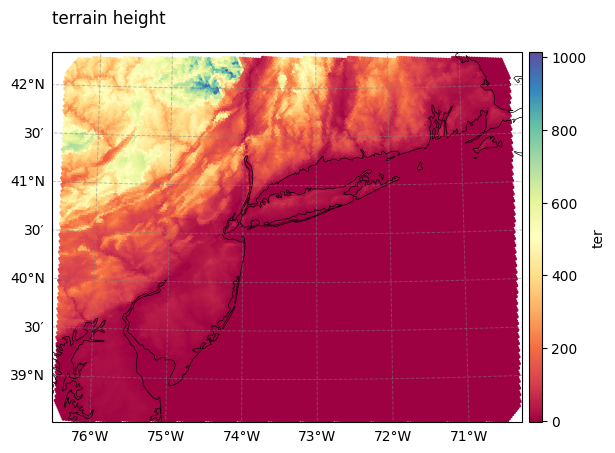

In [6]:
mpasd.show(dta, var_name = 'ter')

## 5. Changing the Colormap (Matplotlib)

MPAS-Viewer supports any valid Matplotlib colormap.

In [7]:
from matplotlib import colormaps

You can list all available Matplotlib colormaps and select one to apply to your visualization.

In [8]:
print(list(colormaps))

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

Changing the color pallete

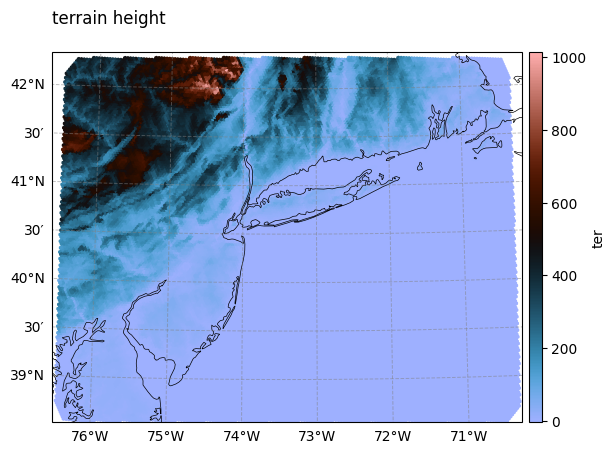

In [9]:
mpasd.show(dta, var_name = 'ter', cmap = 'berlin')

If a specified colormap does not exist, the default colormap will be used automatically.

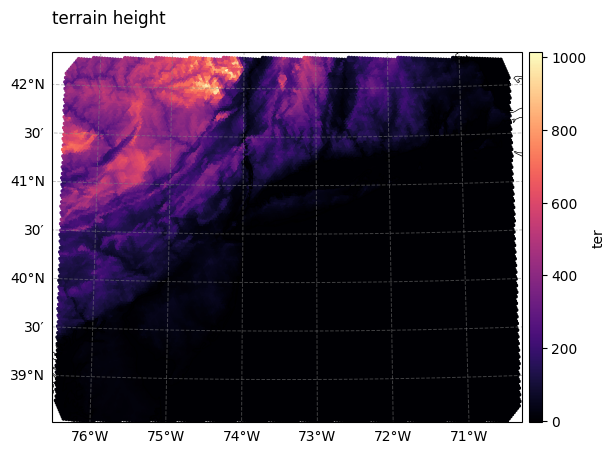

In [10]:
mpasd.show(dta, var_name = 'ter', cmap = 'berlin2')

Also it is possible to set colormap structure

In [11]:
cmap = colormaps["cividis"].resampled(10)

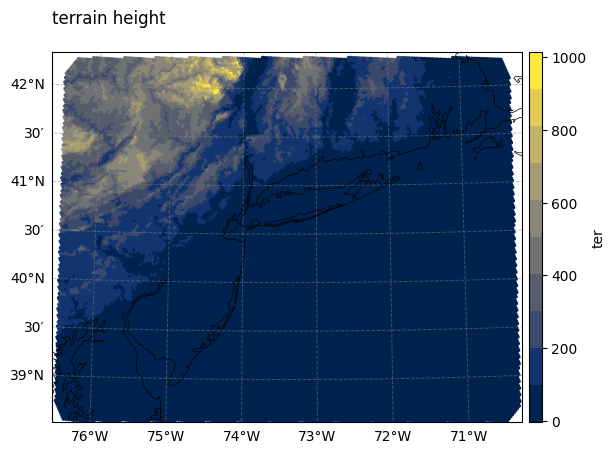

In [12]:
mpasd.show(dta, var_name = 'ter', cmap = cmap)

You can manually control the visualization range by specifying:

- Minimum value (`vmin`)
- Maximum value (`vmax`)

This is especially useful when focusing on specific data intervals or ensuring consistent color scaling across multiple plots.


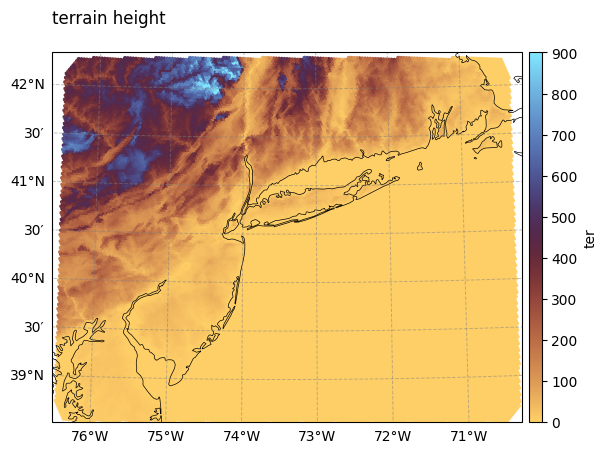

In [13]:
mpasd.show(dta, var_name = 'ter', cmap = 'managua', vmin = 0, vmax = 900)

# Using EarthCMap (Recommended)

The **EarthCMap** library provides scientifically adjusted colormaps tailored for geoscience and environmental data.

Available categories include:

 `['all', 'atmosphere', 'classic', 'earthobs', 'indices', 'land', 'ocean', 'precipitation', 'temperature']`

Using EarthCMap ensures that color scales are appropriate for meteorological and geophysical variables.

You can select a colormap by category and apply both the colormap and its associated normalization for improved scientific consistency.


In [14]:
from earthcmap import escmap

In [15]:
from earthcmap import escmap_list_by_category

In [16]:
# categories = ['all', 'atmosphere', 'classic', 'earthobs', 'indices', 'land', 'ocean', 'precipitation', 'temperature']
dict_cmaps = escmap_list_by_category(category='land')
print(dict_cmaps)

{'land': ['terrain', 'soil_comet', 'soil_usda', 'modis_lu', 'lalc', 'luc', 'laoc', 'mcd12q1', 'modis_igbp']}


In [17]:
cmap, norm = escmap("terrain")

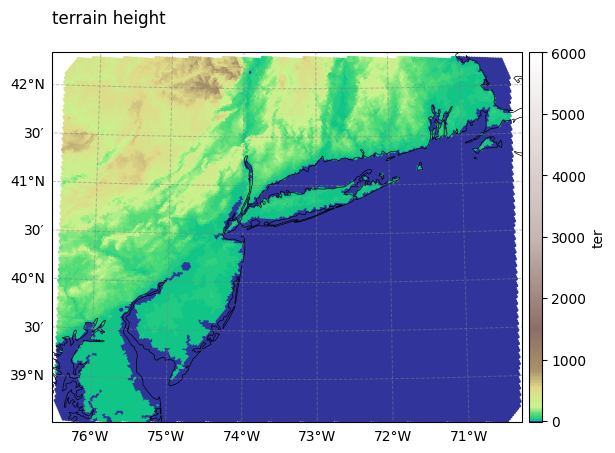

In [18]:
mpasd.show(dta, var_name = 'ter', cmap = cmap, norm = norm)

# Changing the Map Projection

MPAS-Viewer allows changing the default map projection using Cartopy coordinate reference systems.

You can switch to projections such as:

- Mercator
- Lambert Conformal
- Other Cartopy-supported projections

You may also customize projection parameters, such as central longitude and latitude, to better center the region of interest.

In [19]:
import cartopy.crs as ccrs

Modifing to mercator

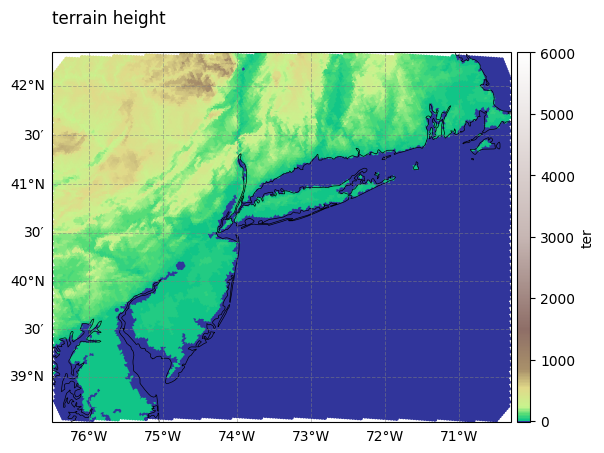

In [20]:
mpasd.show(dta, var_name = 'ter', cmap = cmap, norm = norm, crs = ccrs.Mercator())

Modifing to Lambert

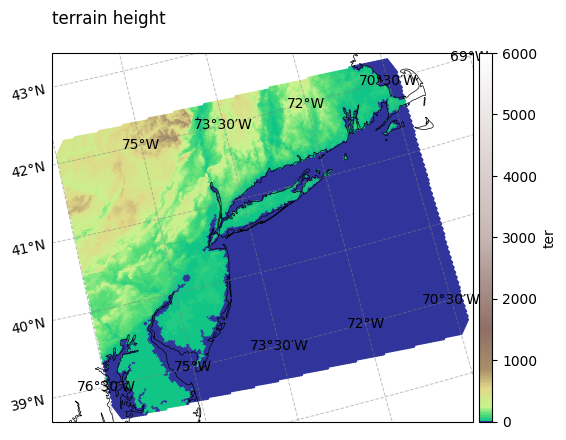

In [21]:
mpasd.show(dta, var_name = 'ter', cmap = cmap, norm = norm, crs = ccrs.LambertConformal())

Modifing to Lambert and changing the postion center

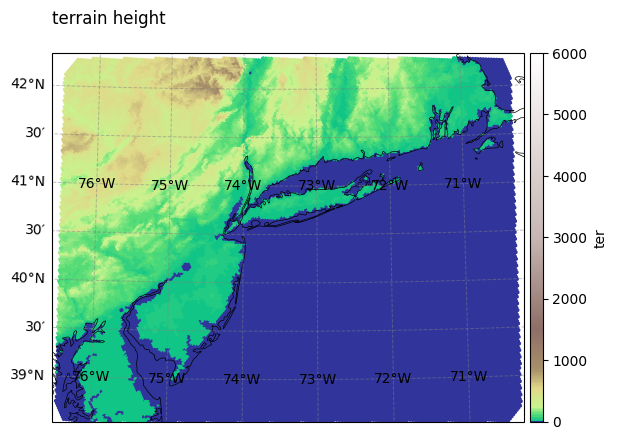

In [22]:
mpasd.show(dta, var_name = 'ter', cmap = cmap, norm = norm, crs=ccrs.LambertConformal(central_longitude=-73.5, central_latitude=40.5))

## Adjusting Figure Size

The figure size can be increased or modified to improve clarity, presentation quality, or suitability for publications and reports.

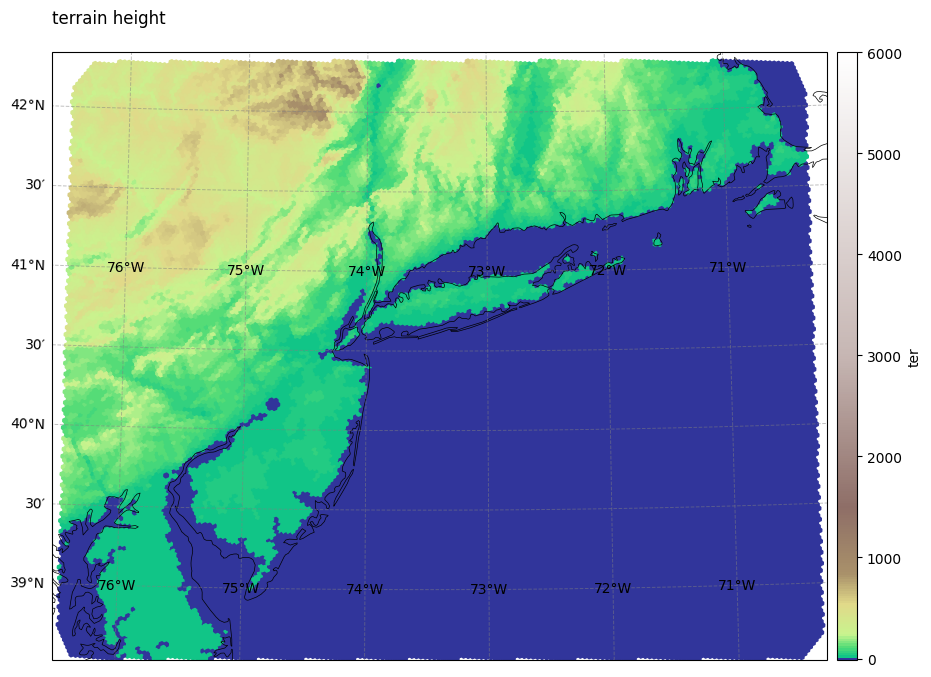

In [23]:
mpasd.show(dta, var_name = 'ter', cmap = cmap, norm = norm, crs = ccrs.LambertConformal(central_longitude = -73.5, central_latitude = 40.5), figsize = (10, 10))